# figures_paper.ipynb

Main figures for the VAE-HMM convection paper.  
All shared utilities live in [`workflow_paper.py`](../workflow_paper.py).

**Notebook structure**
| Cell | Content |
|------|---------|
| 1 | Imports |
| 2 | Data loading (model → latents → diagnostics → Markov analysis) |
| 3–8 | One figure per cell → saved as PDF in `paper/figures/` |

## 1 · Imports

In [20]:
import sys
sys.path.insert(0, '/Users/sophieabramian/Documents/troposwhere/paper')

import os
import pickle
import importlib
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize as Norm
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d

import workflow_paper as wfp
importlib.reload(wfp)  # always pick up latest changes

# Viz constants
NUM_STATES    = wfp.NUM_STATES
state_colors  = wfp.state_colors
cluster_cmap  = wfp.cluster_cmap
norm_state    = wfp.norm_state
path_save_fig = wfp.FIGURES_DIR
os.makedirs(path_save_fig, exist_ok=True)

## 2 · Data loading

Runs model inference on the full dataset, loads diagnostics, and pre-computes the transition matrix and autocorrelations.  
Everything produced here is reused by all figure cells below.

In [21]:
# ── Model & latents ──────────────────────────────────────────
loader, input_dim = wfp.load_dataloader()
model             = wfp.load_model(input_dim=input_dim)
out               = wfp.extract_latents(model, loader)
embeddings        = out["embeddings"]
states            = out["states"]
emb_pca, pca      = wfp.run_pca(embeddings)
_, state_keep_indices = wfp.keep_closest_latent_samples(embeddings, states)

# ── Diagnostics ───────────────────────────────────────────────
mass_flux = np.load(wfp.PATHS["data_raw"])[:-1]
z_array   = wfp.load_z_array()
s_array   = np.linspace(320, 350, 48)
pw        = np.load(wfp.PATHS["pw"])[:len(states)]
prec      = np.load(wfp.PATHS["prec"])[:len(states)]
cp        = np.load(wfp.PATHS["cpi"])[:-1]
pw_norm   = Norm(vmin=1, vmax=17)
prec_norm = Norm(vmin=0, vmax=6)

# Align mass_flux to embedding length (local data may be shorter)
n = min(len(mass_flux), len(embeddings))
mass_flux = mass_flux[:n]
state_keep_indices_mf = {
    s: idxs[idxs < n]
    for s, idxs in state_keep_indices.items()
    if (idxs < n).any()
}

# ── Transition analysis ───────────────────────────────────────
Tmat     = wfp.compute_transition_matrix(states, NUM_STATES, future=5)
pi       = wfp.stationary_distribution(Tmat)
C_obs    = wfp.indicator_autocorrelation_normalized(states[::5], max_lag=50)
C_markov = wfp.markov_autocorrelation(Tmat, pi, max_lag=50)
cp_bins  = np.quantile(cp[::5], [0.0, 0.75, 1.0])
cp_bins_names = ['moderate cold pools', 'strong cold pools']
C6_cp    = wfp.indicator_autocorrelation_state6_cp(states[::5], cp[::5], cp_bins, max_lag=50)

## Fig. 1 — Latent space clusters (`clusters.pdf`)

PCA scatter of the latent embeddings coloured by state, with marginal density histograms and two example convective life-cycle trajectories (strongly vs weakly organised).

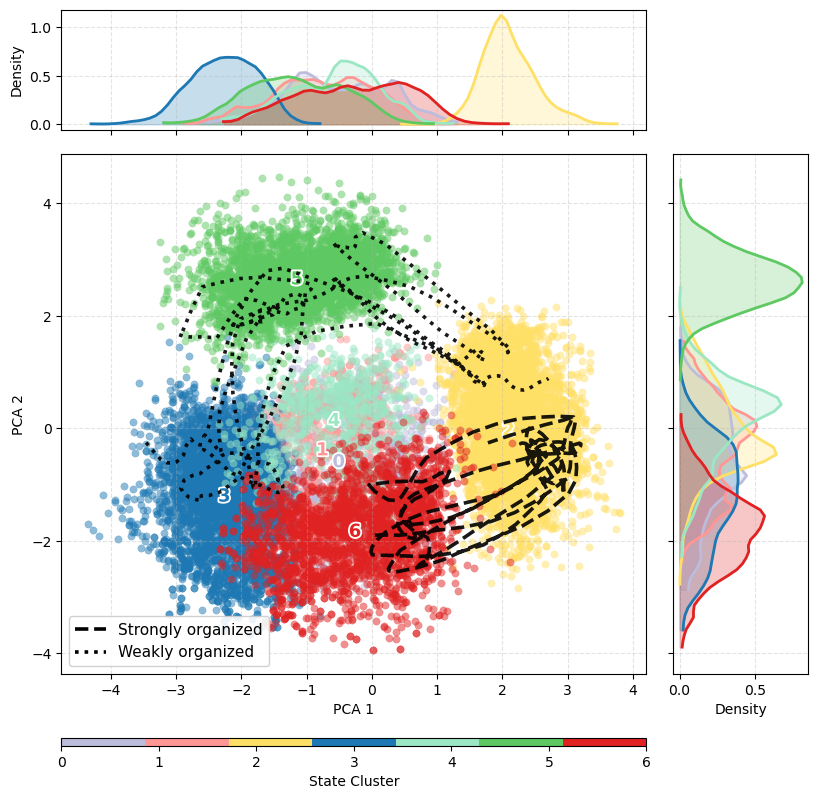

In [22]:
# ── Parameters ───────────────────────────────────────────────
intervals       = [(10000, 10300), (5000, 5300)]
TRAJ_SMOOTH_WIN = 7
#traj_colors     = ["#CC79A7", "#E69F00"]
traj_colors     = ["k", "k"]
traj_styles     = ["--", ":"]

# ── Figure ───────────────────────────────────────────────────
fig      = plt.figure(figsize=(9, 8))
ax_main  = plt.axes([0.12, 0.12, 0.65, 0.65])
ax_top   = plt.axes([0.12, 0.80, 0.65, 0.15], sharex=ax_main)
ax_right = plt.axes([0.80, 0.12, 0.15, 0.65], sharey=ax_main)

unique, counts = np.unique(states, return_counts=True)
count_dict = dict(zip(unique.astype(int), counts.astype(int)))

for s in range(NUM_STATES):
    pts = emb_pca[states == s]
    ax_main.scatter(pts[:, 0], pts[:, 1], s=28, alpha=0.5, linewidth=0.25,
                    facecolors=state_colors[s], label=f"State {s} (n={count_dict.get(s, 0)})")
    hist,  bins  = np.histogram(pts[:, 0], bins=40, density=True)
    cx = (bins[:-1] + bins[1:]) / 2
    ax_top.fill_between(cx, gaussian_filter1d(hist, 1), alpha=0.25, color=state_colors[s])
    ax_top.plot(cx, gaussian_filter1d(hist, 1), color=state_colors[s], lw=2)
    hist2, bins2 = np.histogram(pts[:, 1], bins=40, density=True)
    cy = (bins2[:-1] + bins2[1:]) / 2
    ax_right.fill_betweenx(cy, gaussian_filter1d(hist2, 1), alpha=0.25, color=state_colors[s])
    ax_right.plot(gaussian_filter1d(hist2, 1), cy, color=state_colors[s], lw=2)

# Barycenter labels with repulsion
barycenters = {s: emb_pca[states == s].mean(axis=0) for s in range(NUM_STATES) if (states == s).any()}
shifted = np.array([barycenters[s] for s in range(NUM_STATES)])
for _ in range(200):
    for i in range(NUM_STATES):
        for j in range(i + 1, NUM_STATES):
            diff = shifted[i] - shifted[j]
            dist = np.linalg.norm(diff)
            if dist < 0.12:
                if dist < 1e-6: diff = np.random.randn(2); dist = np.linalg.norm(diff)
                push = 0.003 * diff / dist
                shifted[i] += push; shifted[j] -= push
for s in range(NUM_STATES):
    ax_main.text(*shifted[s], str(s), fontsize=13, fontweight="bold", color=state_colors[s],
                 ha="center", va="center", path_effects=[pe.withStroke(linewidth=2.6, foreground="white")])

# Trajectories
for (t0, t1), ls in zip(intervals, traj_styles):
    traj = wfp.smooth_traj(emb_pca[t0:t1], win=TRAJ_SMOOTH_WIN)
    ax_main.plot(traj[:, 0], traj[:, 1], color="black", lw=2.6, linestyle=ls, alpha=0.9, zorder=30)

ax_main.set_xlabel("PCA 1"); ax_main.set_ylabel("PCA 2")
for a in [ax_main, ax_top, ax_right]:
    a.grid(True, linestyle="--", alpha=0.35)
ax_top.set_ylabel("Density"); ax_right.set_xlabel("Density")
ax_top.tick_params(axis="x", labelbottom=False)
ax_right.tick_params(axis="y", labelleft=False)

sm_cb = ScalarMappable(cmap=cluster_cmap, norm=norm_state); sm_cb.set_array([])
cbar_ax = fig.add_axes([0.12, 0.03, 0.65, 0.01])
cbar = fig.colorbar(sm_cb, cax=cbar_ax, orientation='horizontal')
cbar.set_label("State Cluster")
cbar.set_ticks(np.arange(NUM_STATES)); cbar.set_ticklabels([str(i) for i in range(NUM_STATES)])

traj_handles = [
    Line2D([0], [0], color="black", lw=2.6, linestyle="--", label="Strongly organized"),
    Line2D([0], [0], color="black", lw=2.6, linestyle=":",  label="Weakly organized"),
]
ax_main.legend(handles=traj_handles, loc="lower left", frameon=True, framealpha=0.9, fontsize=11)
plt.savefig(os.path.join(path_save_fig, "clusters.pdf"))
plt.show()

## Fig. 2 — Vertical mass-flux profiles (`vertical_profiles.pdf`)

Per-state anomaly profiles (height × mass-flux) for upward, downward and net mass flux.  
Uses `state_keep_indices_mf` — the closest-to-centroid samples aligned to the local data length.

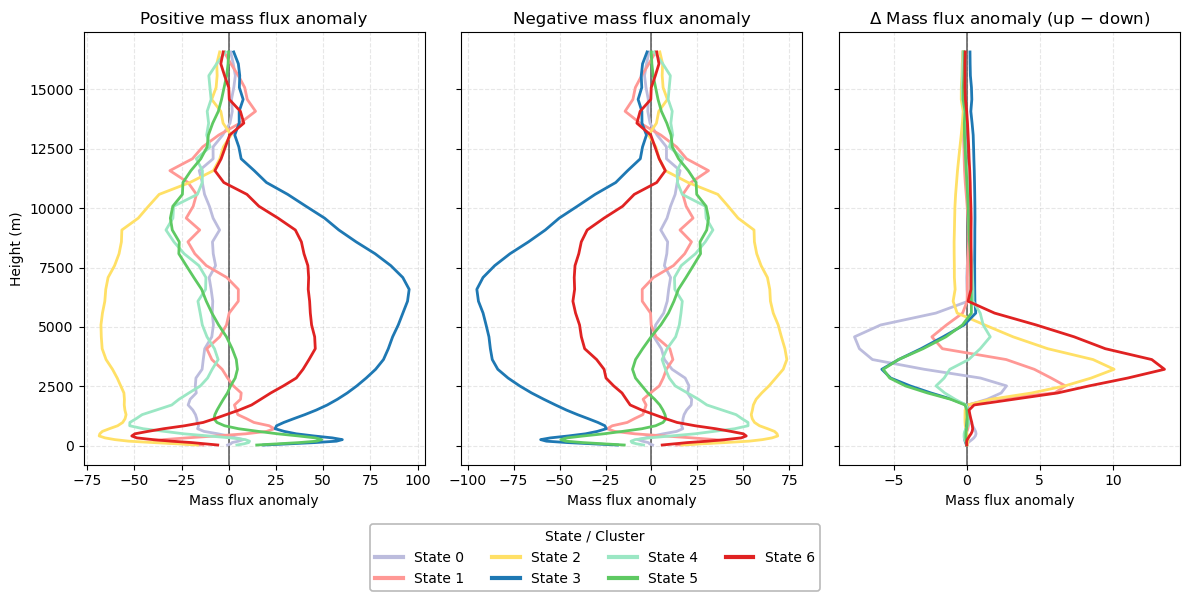

In [23]:
win     = 5
mf_pos  = np.where(mass_flux > 0, mass_flux, 0.0)
mf_neg  = np.where(mass_flux < 0, mass_flux, 0.0)
mf_diff = mf_pos + mf_neg
mf_list = [
    (mf_pos,  "Positive mass flux anomaly"),
    (mf_neg,  "Negative mass flux anomaly"),
    (mf_diff, r"$\Delta$ Mass flux anomaly (up − down)"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)
for ax, (mf, title) in zip(axes, mf_list):
    mf_z   = np.sum(mf, axis=2)
    mean_z = mf_z.mean(axis=0)
    ax.axvline(0.0, color="k", lw=1.2, alpha=0.6)
    for s in range(NUM_STATES):
        idxs = state_keep_indices_mf.get(s)
        if idxs is None or len(idxs) == 0:
            continue
        ax.plot(wfp.smooth_1d(mf_z[idxs].mean(axis=0) - mean_z, win=win), z_array,
                color=state_colors[s], lw=2)
    ax.set_title(title); ax.set_xlabel("Mass flux anomaly")
    ax.grid(True, linestyle="--", alpha=0.3)
axes[0].set_ylabel("Height (m)")

legend_handles = [Line2D([0], [0], color=state_colors[s], lw=3, label=f"State {s}") for s in range(NUM_STATES)]
leg = fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=True,
                 fancybox=True, framealpha=0.9, title="State / Cluster")
leg.get_frame().set_edgecolor("0.7"); leg.get_frame().set_linewidth(1.2)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig(os.path.join(path_save_fig, "vertical_profiles.pdf"), bbox_inches="tight", bbox_extra_artists=(leg,))
plt.show()

## Fig. 3 — MSE profiles (`mse_profiles.pdf`)

Same decomposition as Fig. 2 but plotted along the MSE (moist static energy) axis instead of height.

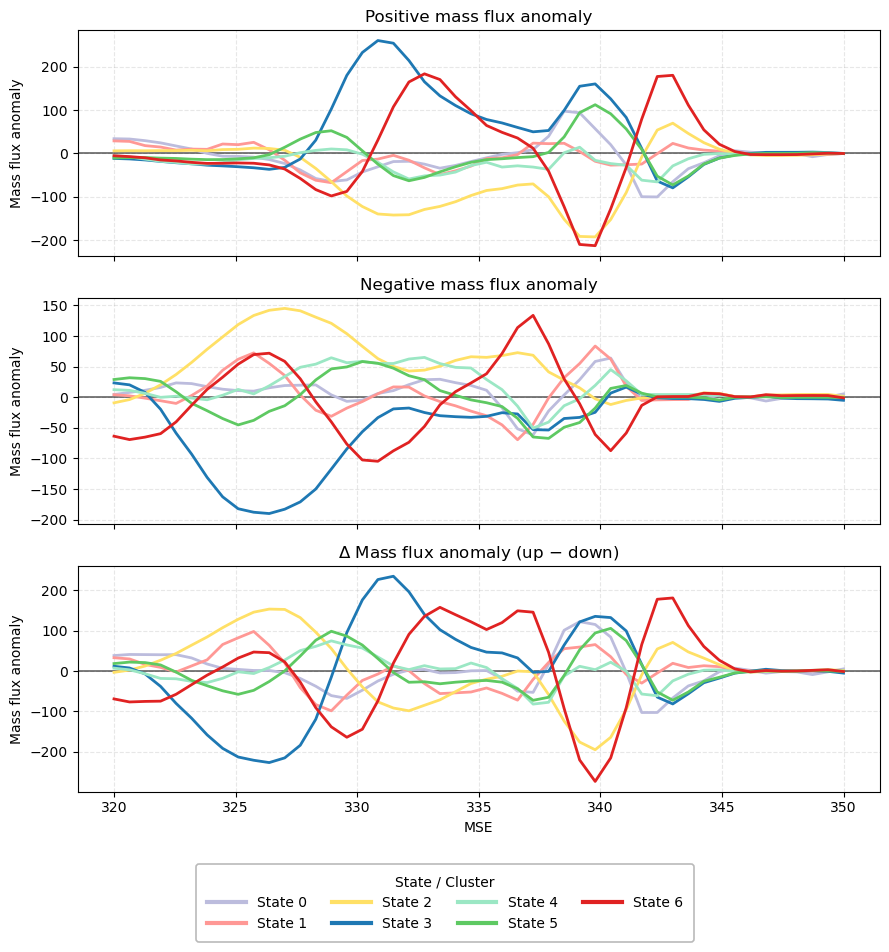

In [24]:
mf_pos  = np.clip(mass_flux, 0.0, None)
mf_neg  = np.clip(mass_flux, None, 0.0)
mf_diff = mf_pos + mf_neg
mf_fields = [
    (mf_pos,  "Positive mass flux anomaly"),
    (mf_neg,  "Negative mass flux anomaly"),
    (mf_diff, r"$\Delta$ Mass flux anomaly (up − down)"),
]

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
for ax, (mf, title) in zip(axes, mf_fields):
    mf_sum       = mf.sum(axis=1)
    mean_profile = mf_sum.mean(axis=0)
    ax.axhline(0.0, color="k", lw=1.2, alpha=0.6)
    for s in range(NUM_STATES):
        idxs = state_keep_indices_mf.get(s)
        if idxs is None or len(idxs) == 0:
            continue
        ax.plot(s_array, wfp.smooth_1d(mf_sum[idxs].mean(axis=0) - mean_profile, win=win),
                color=state_colors[s], lw=2)
    ax.set_title(title); ax.set_ylabel("Mass flux anomaly")
    ax.grid(True, linestyle="--", alpha=0.3)
axes[-1].set_xlabel("MSE")

legend_handles = [Line2D([0], [0], color=state_colors[s], lw=3, label=f"State {s}") for s in range(NUM_STATES)]
leg = fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=True,
                 fancybox=True, framealpha=0.9, title="State / Cluster",
                 bbox_to_anchor=(0.5, -0.06), borderpad=0.8, columnspacing=1.8, handlelength=2.8)
leg.get_frame().set_edgecolor("0.7"); leg.get_frame().set_linewidth(1.2)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(os.path.join(path_save_fig, "mse_profiles.pdf"), bbox_inches="tight")
plt.show()

## Fig. 4 — Latent axes vs diagnostics (`latent_axis.pdf`)

Four-panel figure: PCA space coloured by precipitation and precipitable water (top), and PCA axes vs those diagnostics coloured by state (bottom).

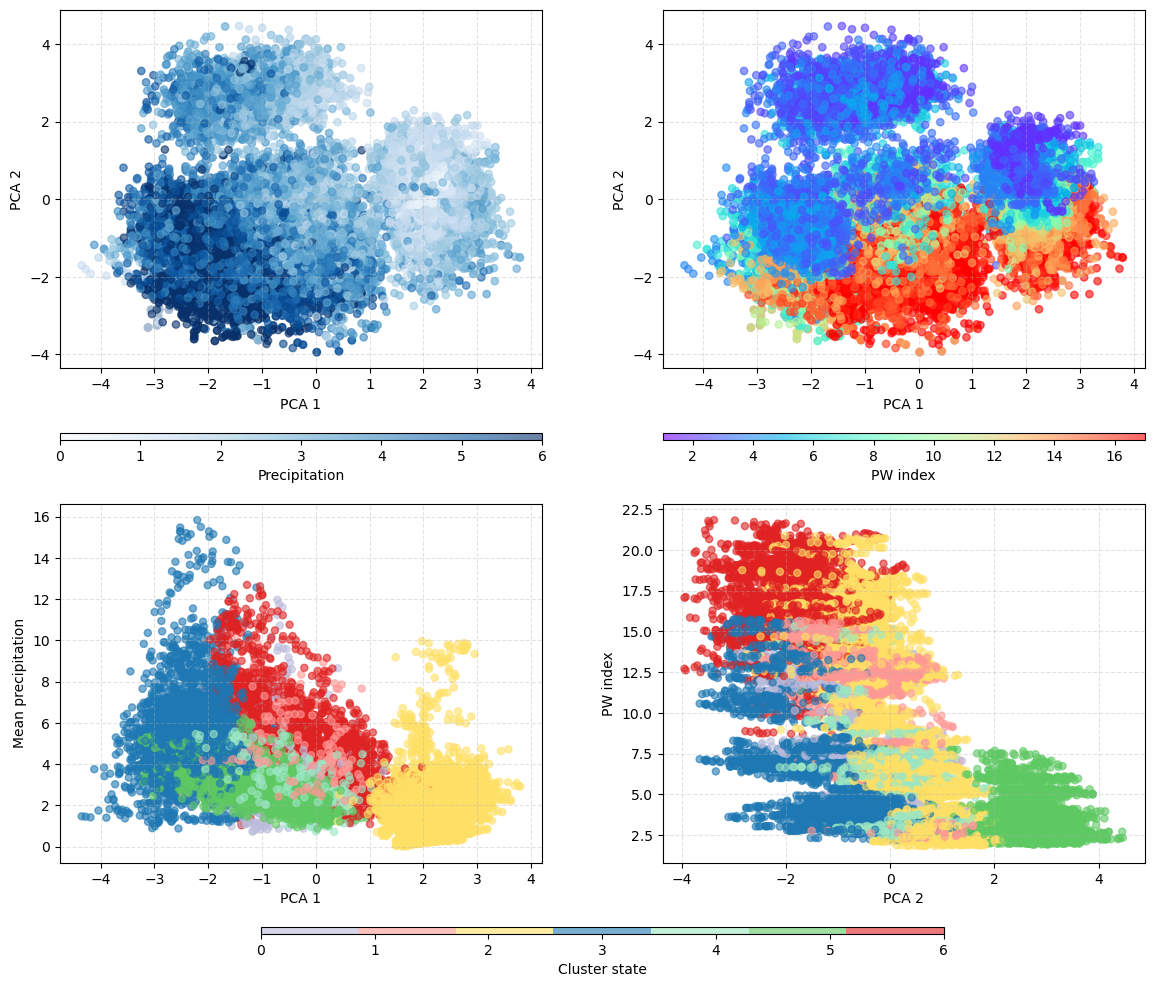

In [25]:
fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(4, 11, height_ratios=[1, 0.02, 1, 0.02], hspace=0.35, wspace=0.25)

ax_tl = fig.add_subplot(gs[0, :5])
ax_tr = fig.add_subplot(gs[0, 6:])
ax_bl = fig.add_subplot(gs[2, :5])
ax_br = fig.add_subplot(gs[2, 6:])
cax_tl     = fig.add_subplot(gs[1, :5])
cax_tr     = fig.add_subplot(gs[1, 6:])
cax_bottom = fig.add_subplot(gs[3, 2:9])

sc_tl = ax_tl.scatter(emb_pca[:, 0], emb_pca[:, 1], c=prec, cmap="Blues",    norm=prec_norm, s=28, alpha=0.6)
sc_tr = ax_tr.scatter(emb_pca[:, 0], emb_pca[:, 1], c=pw,   cmap="rainbow",  norm=pw_norm,   s=28, alpha=0.6)
sc_bl = ax_bl.scatter(emb_pca[:, 0], prec,           c=states, cmap=cluster_cmap, norm=norm_state, s=26, alpha=0.6)
sc_br = ax_br.scatter(emb_pca[:, 1], pw,             c=states, cmap=cluster_cmap, norm=norm_state, s=26, alpha=0.6)

ax_tl.set(xlabel="PCA 1", ylabel="PCA 2")
ax_tr.set(xlabel="PCA 1", ylabel="PCA 2")
ax_bl.set(xlabel="PCA 1", ylabel="Mean precipitation")
ax_br.set(xlabel="PCA 2", ylabel="PW index")
for ax in [ax_tl, ax_tr, ax_bl, ax_br]:
    ax.grid(True, linestyle="--", alpha=0.35)

fig.colorbar(sc_tl, cax=cax_tl, orientation="horizontal").set_label("Precipitation")
fig.colorbar(sc_tr, cax=cax_tr, orientation="horizontal").set_label("PW index")
fig.colorbar(sc_bl, cax=cax_bottom, orientation="horizontal", aspect=110).set_label("Cluster state")

plt.savefig(os.path.join(path_save_fig, "latent_axis.pdf"))
plt.show()

## Fig. 5 — Markov transitions & transition matrix (`markov_matrix.pdf`)

Left: PCA scatter with Bezier arrows proportional to transition probability, state bubbles sized by the stationary distribution π.  
Right: transition matrix as a log-scale heatmap with numerical annotations.

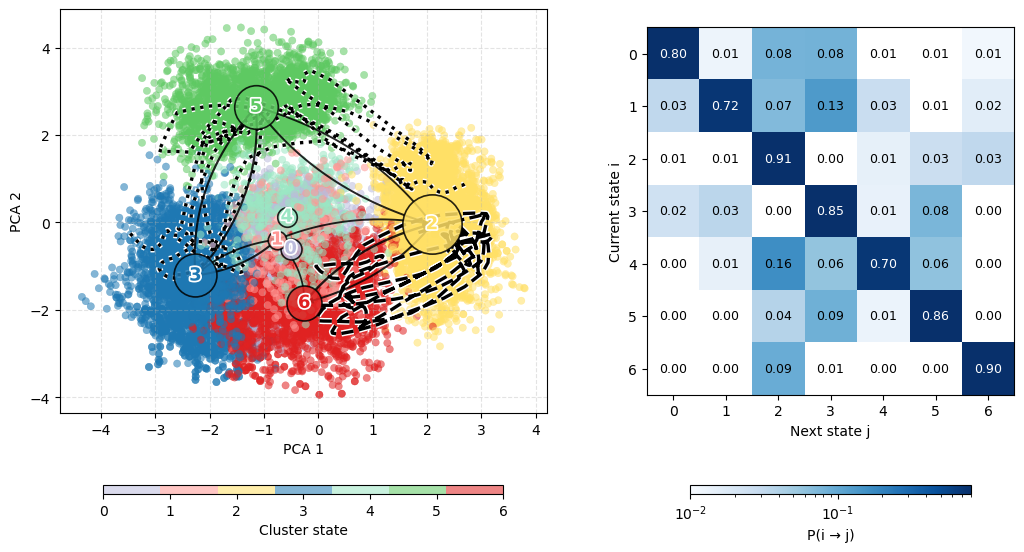

In [26]:
FIGSIZE     = (14, 7)
TRAJ_SMOOTH_WIN = 7
ARROW_STEP  = 6
BUBBLE_SCALE = 5000
TMIN, TMAX  = 0.01, 0.8

bubble_size = BUBBLE_SCALE * pi

fig = plt.figure(figsize=FIGSIZE)
gs  = gridspec.GridSpec(100, 100, hspace=0.30, wspace=0.25)
ax_pca  = fig.add_subplot(gs[10:85,  6:51])
ax_mat  = fig.add_subplot(gs[10:85, 60:94])
cax_pca = fig.add_subplot(gs[98:100, 10:47])
cax_mat = fig.add_subplot(gs[98:100, 64:90])

sc = ax_pca.scatter(emb_pca[:, 0], emb_pca[:, 1], c=states,
                    cmap=cluster_cmap, norm=norm_state, s=28, alpha=0.55, linewidth=0.25)
ax_pca.set(xlabel="PCA 1", ylabel="PCA 2")
ax_pca.grid(True, linestyle="--", alpha=0.35)

bary = np.array([emb_pca[states == s].mean(axis=0) if (states == s).any() else np.zeros(2)
                 for s in range(NUM_STATES)])

for ((t0, t1), col, style) in zip(intervals, traj_colors, traj_styles):
    traj = wfp.smooth_traj(emb_pca[t0:t1], win=TRAJ_SMOOTH_WIN)
    ax_pca.plot(traj[:, 0], traj[:, 1], color=col, linestyle=style, lw=2.4, zorder=20,
                path_effects=[pe.withStroke(linewidth=4.5, foreground="white")])

fig.colorbar(sc, cax=cax_pca, orientation="horizontal", aspect=60, shrink=0.8).set_label("Cluster state")

Tplot    = np.ma.masked_less(Tmat, TMIN)
norm_mat = mcolors.LogNorm(vmin=TMIN, vmax=TMAX)
im = ax_mat.imshow(Tplot, cmap="Blues", norm=norm_mat, origin="upper")
ax_mat.set(xlabel="Next state j", ylabel="Current state i")
for i in range(Tmat.shape[0]):
    for j in range(Tmat.shape[1]):
        ax_mat.text(j, i, f"{Tmat[i, j]:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if Tmat[i, j] > 0.5 * Tmat.max() else "black")
fig.colorbar(im, cax=cax_mat, orientation="horizontal", aspect=60, shrink=0.8).set_label("P(i → j)")

wfp.draw_markov_transitions(ax_pca, Tmat, {s: bary[s] for s in range(NUM_STATES)},
                             min_weight=0.02, min_prob=0.011)

for s in range(NUM_STATES):
    ax_pca.scatter(*bary[s], s=bubble_size[s], color=state_colors[s],
                   edgecolors="black", linewidths=1.2, alpha=0.85, zorder=999)
    ax_pca.text(*bary[s], str(s), fontsize=13, fontweight="bold", color=state_colors[s],
                ha="center", va="center", zorder=1000,
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

for line in ax_pca.lines:
    line.set_rasterized(True)
plt.savefig(os.path.join(path_save_fig, "markov_matrix.pdf"))
plt.show()

## Fig. 6 — Markovianity & cold-pool influence (`markovianity_and_coldpools.pdf`)

Left: per-state indicator autocorrelations vs Markov theory.  
Right: state-6 autocorrelation conditioned on cold-pool intensity (CPI bins), showing how cold pools modulate persistence.

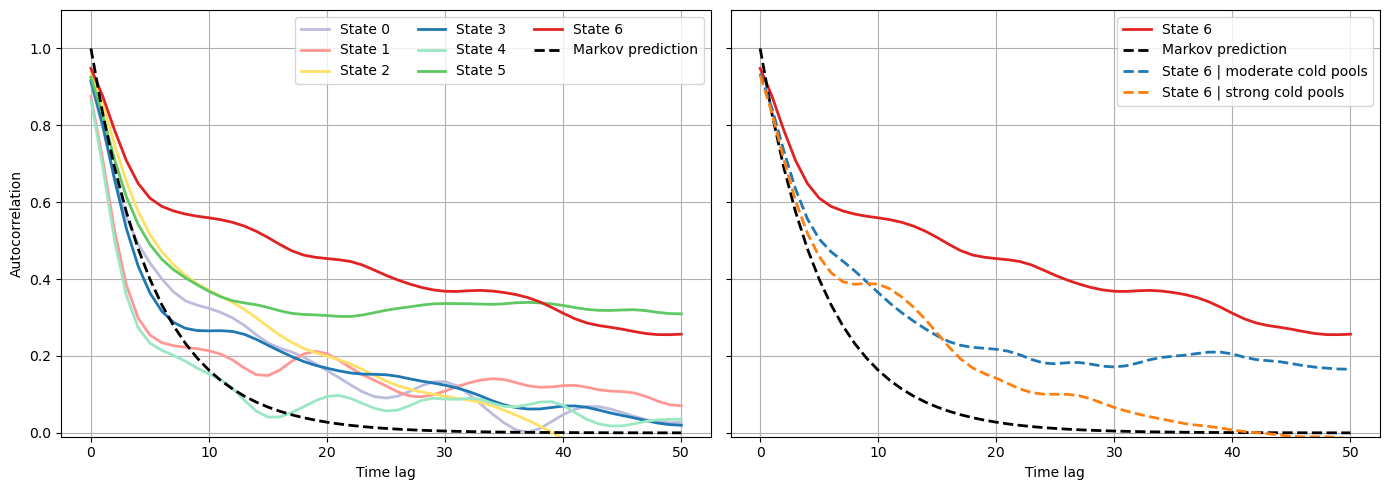

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax = axes[0]
for i, C_ob in enumerate(C_obs):
    ax.plot(wfp.smooth_gaussian(C_ob, sigma=1.2), label=f'State {i}', color=state_colors[i], lw=2)
ax.plot(C_markov, '--', color='k', lw=2, label="Markov prediction")
ax.set_xlabel("Time lag"); ax.set_ylabel("Autocorrelation")
ax.set_ylim(-0.01, 1.1); ax.grid(True); ax.legend(ncols=3)

ax = axes[1]
ax.plot(wfp.smooth_gaussian(C_obs[-1], sigma=1.2), color=state_colors[6], lw=2, label="State 6")
ax.plot(C_markov, '--', color='k', lw=2, label="Markov prediction")
for b in range(len(cp_bins) - 1):
    ax.plot(wfp.smooth_gaussian(C6_cp[b], sigma=1.2), '--', lw=2, label=f"State 6 | {cp_bins_names[b]}")
ax.set_xlabel("Time lag"); ax.set_ylim(-0.01, 1.1); ax.grid(True); ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(path_save_fig, "markovianity_and_coldpools.pdf"))
plt.show()